# GPU 通信原语

> **难度：** 入门 | **时长：** 约 30 分钟

在深入数据并行、张量并行或任何其他并行策略之前，你需要先理解 **GPU 之间是如何通信的**。本 notebook 涵盖每种并行技术都依赖的基本集合通信操作。

## 1. 为什么需要集合通信？

假设 4 个 GPU 在合作训练一个模型。某个时刻它们需要 **共享数据** —— 梯度、激活值、参数。朴素方式：每个 GPU 向其他所有 GPU 发一条消息。4 个 GPU 就是 12 条消息。64 个 GPU 呢？**4,032 条消息**。

**集合通信**解决了这个问题：一次逻辑调用替代成千上万的点对点消息。通信库（NVIDIA GPU 上的 NCCL）在内部处理最优路由。

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from mp_tutorial.distributed import (
    simulate_broadcast, simulate_allreduce, simulate_allgather, simulate_reduce_scatter
)
from mp_tutorial.viz import draw_comm_pattern, draw_p2p_vs_collective, show_matrix, show_matrices_row
from mp_tutorial.formatting import info_box, comparison_table

### 点对点 vs 集合通信 —— 一目了然

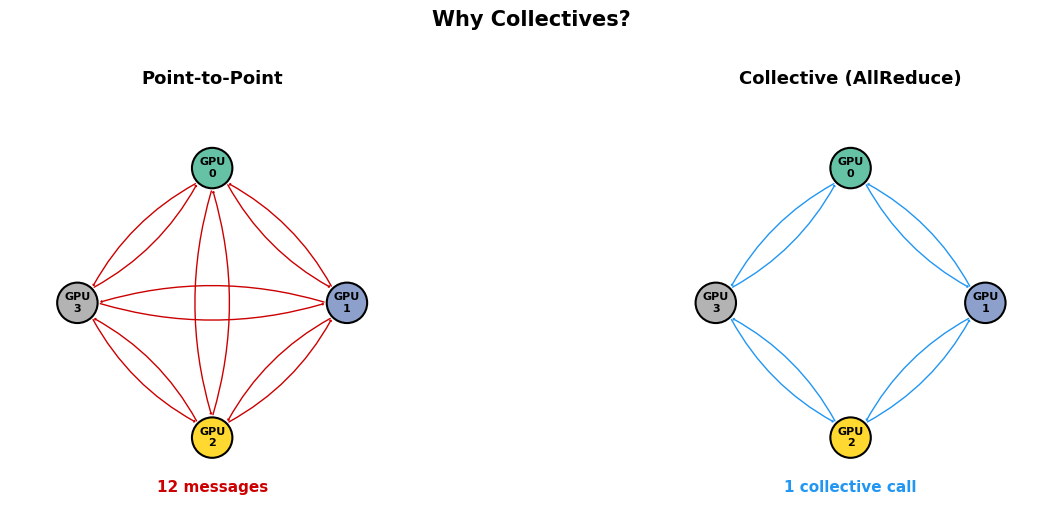

In [2]:
draw_p2p_vs_collective(num_gpus=4)
plt.show()

### 7 种集合通信操作

我们按依赖顺序介绍 —— 先讲简单原语，再讲组合操作：

| # | 操作 | 功能 | 常见用途 |
|---|------|------|----------|
| 1 | **Broadcast** | 从一个 GPU 复制到所有 GPU | 权重初始化 |
| 2 | **Scatter** | 从一个 GPU 拆分并分发 | 数据分发 |
| 3 | **Gather** | 收集到一个 GPU | 结果收集 |
| 4 | **AllGather** | Gather → 每个 GPU 都得到结果 | SP, FSDP |
| 5 | **Reduce** | 求和/聚合到一个 GPU | — |
| 6 | **ReduceScatter** | Reduce → 每个 GPU 得到一个块 | SP, FSDP |
| 7 | **AllReduce** | Reduce → 每个 GPU 都得到结果 | DP 梯度同步 |

---
## 2. Broadcast（广播）

最简单的集合操作：一个 GPU 将数据发送给**所有**其他 GPU。每个 GPU 最终都拥有一份完全相同的副本。

**应用场景：** 训练开始时，将初始模型权重从 GPU 0 分发到所有 GPU。

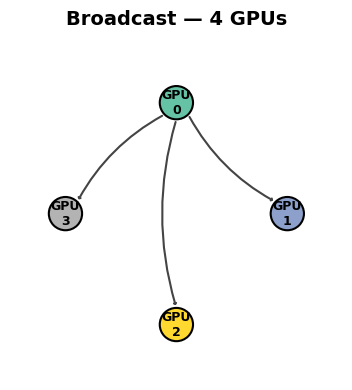

In [3]:
draw_comm_pattern("broadcast", num_gpus=4, figsize=(5, 4))
plt.show()

In [4]:
# GPU 0 有一个张量；其他 GPU 还没有数据
source = torch.tensor([1.0, 2.0, 3.0, 4.0])
print("Broadcast 前：")
print(f"  GPU 0: {source}")
print(f"  GPU 1-3: （空）")

result = simulate_broadcast(source, num_gpus=4)
print("\nBroadcast 后：")
for i, t in enumerate(result):
    print(f"  GPU {i}: {t}")

Broadcast 前：
  GPU 0: tensor([1., 2., 3., 4.])
  GPU 1-3: （空）

Broadcast 后：
  GPU 0: tensor([1., 2., 3., 4.])
  GPU 1: tensor([1., 2., 3., 4.])
  GPU 2: tensor([1., 2., 3., 4.])
  GPU 3: tensor([1., 2., 3., 4.])


/Volumes/workplace/ModelParallelism/src/tinker-model-parallelism/mp_tutorial/viz.py:120: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Volumes/workplace/ModelParallelism/src/tinker-model-parallelism/mp_tutorial/viz.py:120: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Volumes/workplace/ModelParallelism/src/tinker-model-parallelism/mp_tutorial/viz.py:120: UserWarning: Glyph 25152 (\N{CJK UNIFIED IDEOGRAPH-6240}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Volumes/workplace/ModelParallelism/src/tinker-model-parallelism/mp_tutorial/viz.py:120: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Volumes/workplace/ModelParallelism/src/tinker-model-parallelism/mp_tutorial/viz.py:120: UserWarning: Glyph 25317 (\N{CJK UNIFIED IDEOGRAPH-62E5}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/

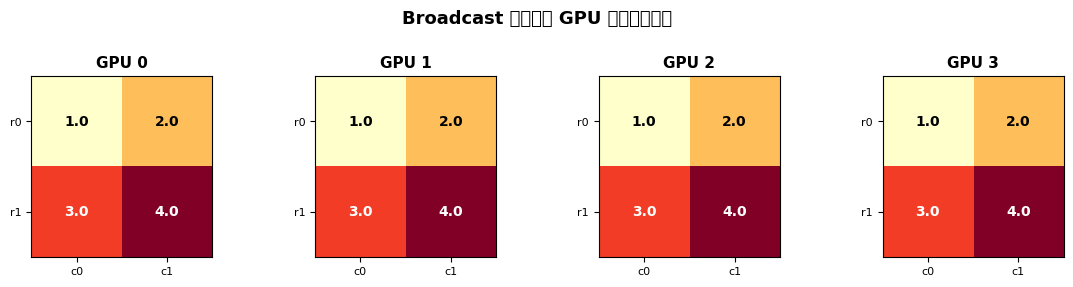

In [5]:
# 可视化：一个源 → 四份相同的副本
source = torch.tensor([[1., 2.], [3., 4.]])
result = simulate_broadcast(source, num_gpus=4)
show_matrices_row(result, titles=[f"GPU {i}" for i in range(4)], suptitle="Broadcast 后：所有 GPU 拥有相同数据")
plt.show()

---
## 3. Scatter（散射）

根节点 GPU **拆分**数据为 N 块，将第 *i* 块发送给 GPU *i*。每个 GPU 得到**不同的**部分。

**应用场景：** 将训练数据的 batch 分发到各 GPU —— 每个 GPU 处理不同部分。

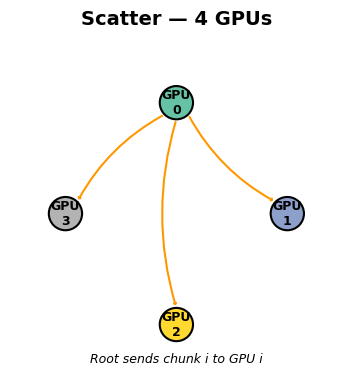

In [6]:
draw_comm_pattern("scatter", num_gpus=4, figsize=(5, 4))
plt.show()

In [7]:
# GPU 0 有一个要分发的大张量
data = torch.arange(12).reshape(4, 3).float()
print("Scatter 前（GPU 0 拥有）：")
print(data)

# Scatter：沿 dim 0 拆分成 4 块
chunks = list(data.chunk(4, dim=0))
print("\nScatter 后：")
for i, chunk in enumerate(chunks):
    print(f"  GPU {i}: {chunk.squeeze()}")

Scatter 前（GPU 0 拥有）：
tensor([[ 0.,  1.,  2.],
        [ 3.,  4.,  5.],
        [ 6.,  7.,  8.],
        [ 9., 10., 11.]])

Scatter 后：
  GPU 0: tensor([0., 1., 2.])
  GPU 1: tensor([3., 4., 5.])
  GPU 2: tensor([6., 7., 8.])
  GPU 3: tensor([ 9., 10., 11.])


In [ ]:
# Scatter 可视化：一个完整矩阵 → 四个不同的块
fig, axes = plt.subplots(1, 6, figsize=(15, 2.5), gridspec_kw={'width_ratios': [4, 0.5, 1, 1, 1, 1]})

data = torch.arange(12).reshape(4, 3).float()
show_matrix(data, ax=axes[0], title="GPU 0 (before)")

axes[1].text(0.5, 0.5, "→", fontsize=28, ha='center', va='center', fontweight='bold')
axes[1].axis('off')

chunks = list(data.chunk(4, dim=0))
for i, chunk in enumerate(chunks):
    show_matrix(chunk, ax=axes[i+2], title=f"GPU {i}")

fig.suptitle("Scatter: split & distribute", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 4. Gather（收集）

**Scatter 的逆操作**：每个 GPU 将数据发送到根节点 GPU，根节点将它们拼接起来。

**应用场景：** 将所有 GPU 的部分结果收集到一个 GPU 上，用于记录日志或保存检查点。

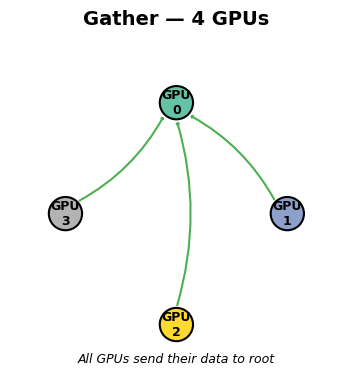

In [8]:
draw_comm_pattern("gather", num_gpus=4, figsize=(5, 4))
plt.show()

In [9]:
# 每个 GPU 计算了一个部分结果
partials = [torch.tensor([i * 10 + j for j in range(3)]).float() for i in range(4)]
print("Gather 前：")
for i, p in enumerate(partials):
    print(f"  GPU {i}: {p}")

# Gather：在根节点拼接
gathered = torch.cat(partials, dim=0)
print(f"\nGather 后（GPU 0）: {gathered}")

Gather 前：
  GPU 0: tensor([0., 1., 2.])
  GPU 1: tensor([10., 11., 12.])
  GPU 2: tensor([20., 21., 22.])
  GPU 3: tensor([30., 31., 32.])

Gather 后（GPU 0）: tensor([ 0.,  1.,  2., 10., 11., 12., 20., 21., 22., 30., 31., 32.])


In [ ]:
# Gather 可视化：各 GPU 的部分 → 根节点的完整数据
partials = [torch.tensor([[i * 10 + j for j in range(3)]]).float() for i in range(4)]
gathered = torch.cat(partials, dim=0)

fig, axes = plt.subplots(1, 6, figsize=(16, 2.5), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.5, 4]})
for i in range(4):
    show_matrix(partials[i], ax=axes[i], title=f"GPU {i}")

axes[4].text(0.5, 0.5, "→", fontsize=28, ha='center', va='center', fontweight='bold')
axes[4].axis('off')

show_matrix(gathered, ax=axes[5], title="GPU 0 (after)")
fig.suptitle("Gather: collect onto root", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

---
## 5. AllGather（全收集）

和 Gather 一样，但**每个** GPU 都能得到完整的拼接结果 —— 不仅仅是根节点。

$$\text{AllGather} = \text{Gather} + \text{Broadcast}$$

**应用场景：** 在序列并行（SP）中，每个 GPU 持有一个序列分块；在进入 TP 层之前，AllGather 在每个 GPU 上重建完整序列。

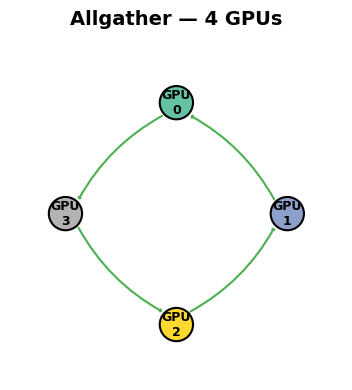

In [10]:
draw_comm_pattern("allgather", num_gpus=4, figsize=(5, 4))
plt.show()

In [11]:
# 每个 GPU 持有序列的一个分块
chunks = [torch.tensor([[i, i+0.5]]) for i in range(4)]
print("AllGather 前（每个 GPU 有自己的分块）：")
for i, c in enumerate(chunks):
    print(f"  GPU {i}: {c.squeeze()}")

result = simulate_allgather(chunks)
print("\nAllGather 后（每个 GPU 拥有完整序列）：")
for i, r in enumerate(result):
    print(f"  GPU {i}: {r}")

AllGather 前（每个 GPU 有自己的分块）：
  GPU 0: tensor([0.0000, 0.5000])
  GPU 1: tensor([1.0000, 1.5000])
  GPU 2: tensor([2.0000, 2.5000])
  GPU 3: tensor([3.0000, 3.5000])

AllGather 后（每个 GPU 拥有完整序列）：
  GPU 0: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 1: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 2: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])
  GPU 3: tensor([[0.0000, 0.5000],
        [1.0000, 1.5000],
        [2.0000, 2.5000],
        [3.0000, 3.5000]])


In [ ]:
# AllGather 可视化：各 GPU 有一块 → 所有 GPU 有完整数据
chunks = [torch.tensor([[i, i + 0.5]]) for i in range(4)]
full = torch.cat(chunks, dim=0)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("AllGather: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(chunks[i], ax=axes[0, i], title=f"GPU {i} (before)")
for i in range(4):
    show_matrix(full, ax=axes[1, i], title=f"GPU {i} (after)")

plt.tight_layout()
plt.show()

---
## 6. Reduce（归约）

所有 GPU 贡献一个张量；对它们求**和**（或其他操作如取最大值），结果**仅**落在根节点 GPU 上。

$$\text{Reduce}(\text{GPU}_0, \text{GPU}_1, \ldots) = \sum_i \text{GPU}_i \quad \text{（结果仅在根节点）}$$

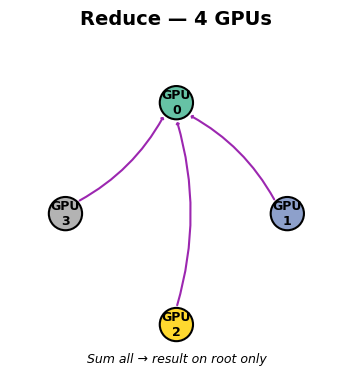

In [12]:
draw_comm_pattern("reduce", num_gpus=4, figsize=(5, 4))
plt.show()

In [13]:
# 每个 GPU 计算了本地梯度
grads = [torch.tensor([1.0, 2.0, 3.0]) * (i + 1) for i in range(4)]
print("Reduce 前（每个 GPU 的梯度）：")
for i, g in enumerate(grads):
    print(f"  GPU {i}: {g}")

# Reduce：求和到 GPU 0
reduced = torch.stack(grads).sum(dim=0)
print(f"\nReduce 后（仅 GPU 0）: {reduced}")
print(f"  GPU 1-3:（没有结果）")

Reduce 前（每个 GPU 的梯度）：
  GPU 0: tensor([1., 2., 3.])
  GPU 1: tensor([2., 4., 6.])
  GPU 2: tensor([3., 6., 9.])
  GPU 3: tensor([ 4.,  8., 12.])

Reduce 后（仅 GPU 0）: tensor([10., 20., 30.])
  GPU 1-3:（没有结果）


In [ ]:
# Reduce 可视化：各 GPU 有数据 → 仅根节点有总和
grads = [torch.tensor([[1.0, 2.0, 3.0]]) * (i + 1) for i in range(4)]
reduced = torch.stack([g.squeeze() for g in grads]).sum(dim=0, keepdim=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 4))
fig.suptitle("Reduce: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(grads[i], ax=axes[0, i], title=f"GPU {i}")
show_matrix(reduced, ax=axes[1, 0], title="GPU 0 = sum")
for i in range(1, 4):
    axes[1, i].text(0.5, 0.5, "—", fontsize=24, ha='center', va='center', color='#ccc')
    axes[1, i].set_title(f"GPU {i}", fontsize=10, color='#ccc')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

---
## 7. ReduceScatter（归约散射）

**一步完成 Reduce + Scatter**：对所有张量求和，然后拆分结果，将第 *i* 块分配给 GPU *i*。每个 GPU 得到求和结果的**不同分块**。

$$\text{ReduceScatter} = \text{Reduce} + \text{Scatter}$$

**应用场景：** 在 SP 中，TP 行并行层之后，ReduceScatter 对部分激活求和并将序列分块分发回各 GPU。

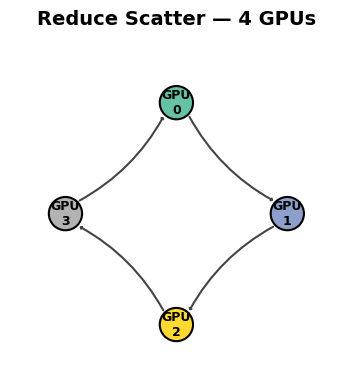

In [14]:
draw_comm_pattern("reduce_scatter", num_gpus=4, figsize=(5, 4))
plt.show()

In [15]:
# 每个 GPU 有一个部分激活张量（各 4 行）
partials = [torch.ones(4, 2) * (i + 1) for i in range(4)]
print("ReduceScatter 前：")
for i, p in enumerate(partials):
    print(f"  GPU {i}: 总和={p.sum().item():.0f}  形状={tuple(p.shape)}")

result = simulate_reduce_scatter(partials)
print("\nReduceScatter 后（每个 GPU 得到总和的一块）：")
for i, r in enumerate(result):
    print(f"  GPU {i}: {r.squeeze()}  形状={tuple(r.shape)}")

ReduceScatter 前：
  GPU 0: 总和=8  形状=(4, 2)
  GPU 1: 总和=16  形状=(4, 2)
  GPU 2: 总和=24  形状=(4, 2)
  GPU 3: 总和=32  形状=(4, 2)

ReduceScatter 后（每个 GPU 得到总和的一块）：
  GPU 0: tensor([10., 10.])  形状=(1, 2)
  GPU 1: tensor([10., 10.])  形状=(1, 2)
  GPU 2: tensor([10., 10.])  形状=(1, 2)
  GPU 3: tensor([10., 10.])  形状=(1, 2)


In [ ]:
# ReduceScatter 可视化：各 GPU 有完整数据 → 各得总和的一块
partials = [torch.arange(8).reshape(4, 2).float() + (i * 10) for i in range(4)]
total = torch.stack(partials).sum(dim=0)
rs_chunks = list(total.chunk(4, dim=0))

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("ReduceScatter: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(partials[i], ax=axes[0, i], title=f"GPU {i}")
for i in range(4):
    show_matrix(rs_chunks[i], ax=axes[1, i], title=f"GPU {i} (chunk {i} of sum)")

plt.tight_layout()
plt.show()

---
## 8. AllReduce（全归约）

分布式训练中最重要的集合操作。对所有张量求和，**每个 GPU 都得到完整结果**。

$$\text{AllReduce} = \text{ReduceScatter} + \text{AllGather}$$

（或等价地，Reduce + Broadcast）

**应用场景：** 在数据并行（DP）中，每个 GPU 在自己的 batch 上计算梯度，然后 AllReduce 对梯度求平均，确保每个 GPU 拥有相同的梯度用于优化器更新。

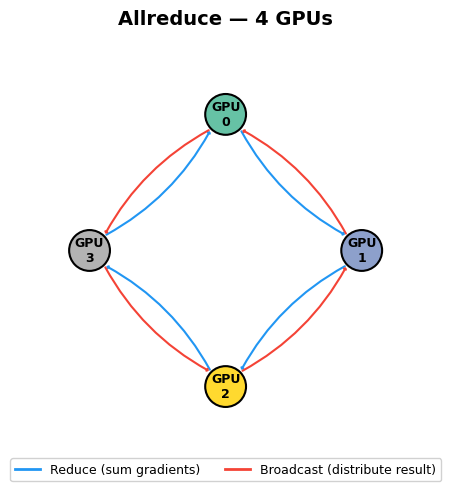

In [16]:
draw_comm_pattern("allreduce", num_gpus=4, figsize=(6, 5))
plt.show()

In [17]:
# 每个 GPU 有自己 mini-batch 的本地梯度
torch.manual_seed(42)
local_grads = [torch.randn(2, 3).round() for _ in range(4)]
print("AllReduce 前（每个 GPU 的本地梯度）：")
for i, g in enumerate(local_grads):
    print(f"  GPU {i}:")
    print(f"    {g[0].tolist()}")
    print(f"    {g[1].tolist()}")

result = simulate_allreduce(local_grads)
print("\nAllReduce 后（每个 GPU 都有总和）：")
print(f"  所有 GPU: {result[0]}")
# 验证全部相同
assert all(torch.equal(result[0], r) for r in result), "不匹配！"
print("  ✓ 所有 GPU 拥有完全相同的张量")

AllReduce 前（每个 GPU 的本地梯度）：
  GPU 0:
    [0.0, 0.0, 0.0]
    [0.0, -1.0, -0.0]
  GPU 1:
    [2.0, -1.0, 0.0]
    [0.0, 1.0, 1.0]
  GPU 2:
    [1.0, -2.0, -1.0]
    [1.0, 1.0, 1.0]
  GPU 3:
    [-1.0, -1.0, 1.0]
    [1.0, -0.0, 1.0]

AllReduce 后（每个 GPU 都有总和）：
  所有 GPU: tensor([[ 2., -4.,  0.],
        [ 2.,  1.,  3.]])
  ✓ 所有 GPU 拥有完全相同的张量


In [ ]:
# AllReduce 可视化：各 GPU 有本地梯度 → 所有 GPU 有总和
torch.manual_seed(0)
local = [torch.tensor([[1., 2.], [3., 4.]]) * (i + 1) for i in range(4)]
summed = torch.stack(local).sum(dim=0)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
fig.suptitle("AllReduce: before (top) → after (bottom)", fontsize=13, fontweight='bold')

for i in range(4):
    show_matrix(local[i], ax=axes[0, i], title=f"GPU {i}")
for i in range(4):
    show_matrix(summed, ax=axes[1, i], title=f"GPU {i} = sum")

plt.tight_layout()
plt.show()

### AllReduce = ReduceScatter + AllGather

在实际实现中，AllReduce 分两步完成。这就是 **Ring AllReduce** 算法 —— 传输的总数据量相同，但在各 GPU 之间形成流水线：

1. **ReduceScatter**：求和 & 分发分块（每个 GPU 得到 1/N 的结果）
2. **AllGather**：大家共享各自的分块（每个 GPU 重建完整结果）

In [18]:
# 演示 AllReduce = ReduceScatter + AllGather
grads = [torch.tensor([1., 2., 3., 4.]) * (i + 1) for i in range(4)]
print("输入梯度：", [g.tolist() for g in grads])

# 第 1 步：ReduceScatter
rs_result = simulate_reduce_scatter(grads)
print("\n第 1 步 — ReduceScatter（每个 GPU 有总和的一块）：")
for i, r in enumerate(rs_result):
    print(f"  GPU {i}: {r.tolist()}")

# 第 2 步：AllGather
ag_result = simulate_allgather(rs_result)
print("\n第 2 步 — AllGather（在所有 GPU 上重建完整结果）：")
for i, r in enumerate(ag_result):
    print(f"  GPU {i}: {r.tolist()}")

# 验证：与直接 AllReduce 结果相同
direct = simulate_allreduce(grads)
assert torch.equal(ag_result[0], direct[0])
print("\n✓ ReduceScatter + AllGather == AllReduce")

输入梯度： [[1.0, 2.0, 3.0, 4.0], [2.0, 4.0, 6.0, 8.0], [3.0, 6.0, 9.0, 12.0], [4.0, 8.0, 12.0, 16.0]]

第 1 步 — ReduceScatter（每个 GPU 有总和的一块）：
  GPU 0: [10.0]
  GPU 1: [20.0]
  GPU 2: [30.0]
  GPU 3: [40.0]

第 2 步 — AllGather（在所有 GPU 上重建完整结果）：
  GPU 0: [10.0, 20.0, 30.0, 40.0]
  GPU 1: [10.0, 20.0, 30.0, 40.0]
  GPU 2: [10.0, 20.0, 30.0, 40.0]
  GPU 3: [10.0, 20.0, 30.0, 40.0]

✓ ReduceScatter + AllGather == AllReduce


---
## 9. 点对点通信 (Send / Recv)

不是集合操作 —— 是两个特定 GPU 之间的**直接消息**。用于通信模式不规则或特定于某算法的场景。

**应用场景：** 流水线并行（PP）将激活从第 *i* 阶段发送到第 *i+1* 阶段。Ring Attention（CP）在环上轮换 KV 块。

---
## 10. 带宽 vs 延迟

两个因素决定通信开销：

| 因素 | 含义 | 类比 |
|------|------|------|
| **延迟 (Latency)** | 每条消息的固定开销（μs） | 拿起电话的时间 |
| **带宽 (Bandwidth)** | 数据传输速率（GB/s） | 说话的速度 |

$$\text{时间} = \text{延迟} + \frac{\text{消息大小}}{\text{带宽}}$$

**核心洞察：** 对于大消息（梯度、激活），带宽起主导作用。集合通信的设计目标是**最大化所有 GPU 的带宽利用率**。

| 互连方式 | 带宽 | 典型用途 |
|----------|------|----------|
| NVLink（节点内） | 600-900 GB/s | TP, SP（同一台机器） |
| PCIe 5.0 | 64 GB/s | 节点内后备方案 |
| InfiniBand / RoCE（节点间） | 50-400 GB/s | DP, PP（跨机器） |

这就是为什么 **TP 局限在单个节点内**（需要 NVLink 速度），而 **DP 和 PP 可以跨节点**（每步通信量更少）。

---
## 总结

| 操作 | 输入 → 输出 | 每个 GPU 都得到结果？ | 主要用途 |
|------|-----------|---------------------|---------|
| **Broadcast** | 1 → 全部（复制） | ✓ | 权重初始化 |
| **Scatter** | 1 → 全部（拆分） | 各得一块 | 数据分发 |
| **Gather** | 全部 → 1（拼接） | 仅根节点 | 结果收集 |
| **AllGather** | 全部 → 全部（拼接） | ✓ | SP, FSDP |
| **Reduce** | 全部 → 1（求和） | 仅根节点 | — |
| **ReduceScatter** | 全部 → 全部（求和+拆分） | 各得一块 | SP, FSDP |
| **AllReduce** | 全部 → 全部（求和） | ✓ | DP 梯度同步 |

### 组合规则

```
AllGather    = Gather    + Broadcast
AllReduce    = Reduce    + Broadcast
AllReduce    = ReduceScatter + AllGather   ← Ring 算法
```

### 延伸阅读

- [NCCL 文档](https://docs.nvidia.com/deeplearning/nccl/user-guide/docs/overview.html) — NVIDIA 集合通信库
- [Megatron-LM 论文 (2020)](https://arxiv.org/abs/1909.08053) — 集合通信如何支撑大规模模型并行
- 下一篇 notebook：**[01-数据并行](../01-data-parallelism/01-data-parallelism.zh.ipynb)** — 看 AllReduce 实战